In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Seaborn

### Exercise 1

In [61]:
df = pd.read_csv("mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


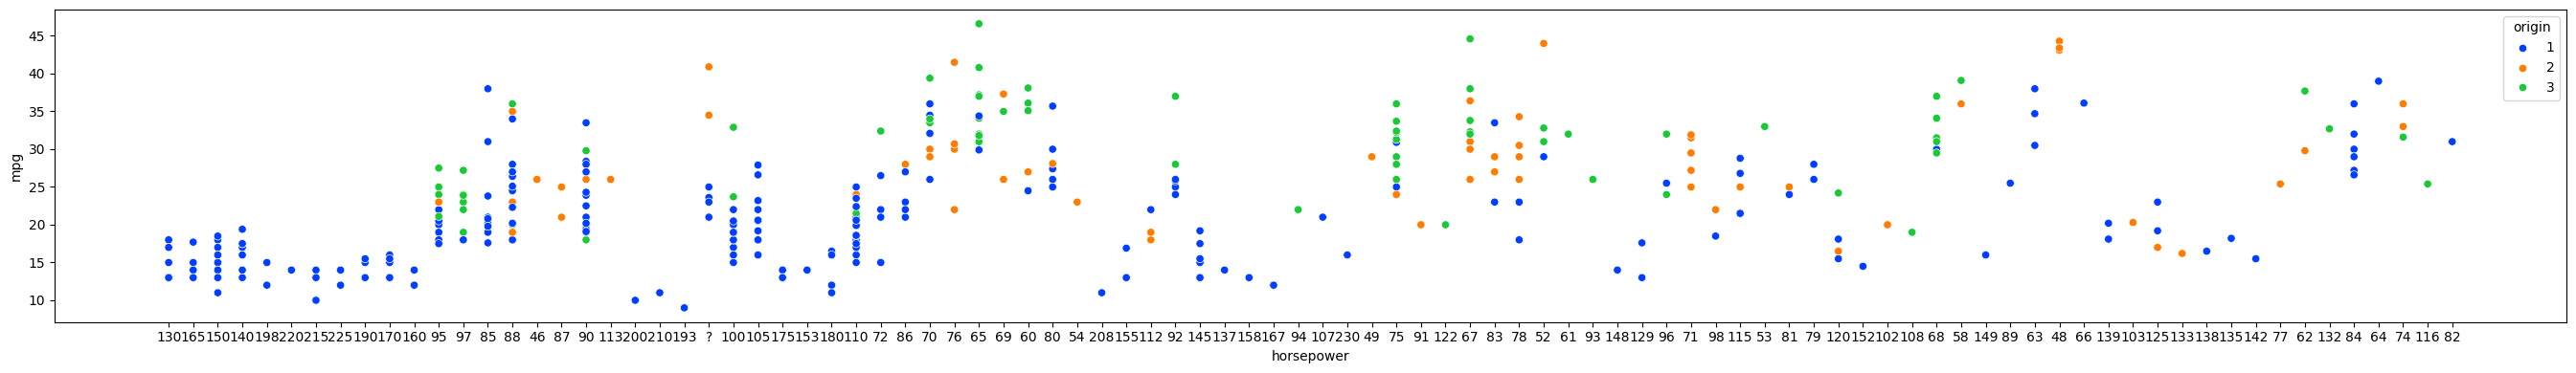

In [54]:
plt.figure(figsize=(27, 4))
sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin', palette='bright')
plt.tight_layout()
plt.show()

### Exercise 2

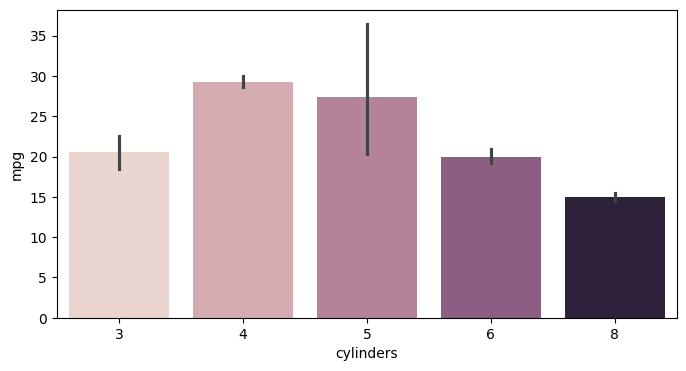

In [79]:
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='cylinders', y='mpg', hue='cylinders', legend=False)
plt.show()

### Exercise 3

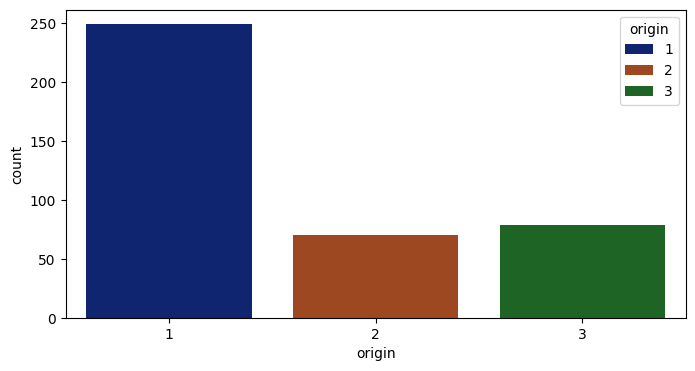

In [84]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='origin', hue='origin', palette='dark')
plt.show()

### Exercise 4

<Figure size 800x400 with 0 Axes>

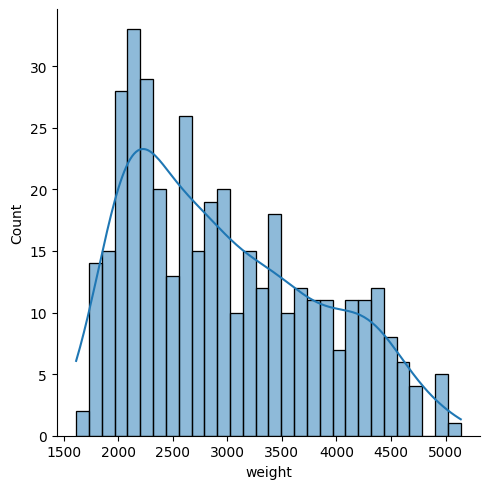

In [98]:
plt.figure(figsize=(8, 4))
sns.displot(data=df, x='weight', bins=30, kde=True)
plt.show()

### Exercise 5

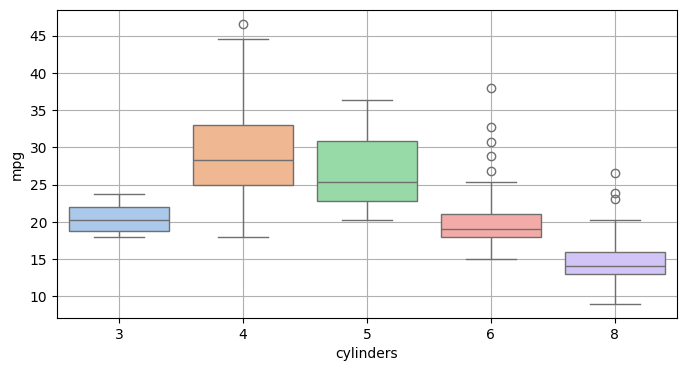

In [110]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='cylinders', y='mpg', hue='cylinders', palette='pastel', legend=False)
plt.grid()
plt.show()

## Pandas

In [115]:
books = pd.read_csv("books.csv")
books_sales = pd.read_csv("books_sales.csv")

In [205]:
books_df = books.copy()
books_sales_df = books_sales.copy()

print("Step 1")
books_dup = books_df[books_df['catalog_number'].duplicated(keep=False)].sort_values('catalog_number')
display(books_dup)

print("Step 2")
books_dup['not_nan_count'] = books_dup.notna().sum(axis=1)
books_dup.sort_values(['catalog_number', 'not_nan_count'], ascending=[True, False], inplace=True)
display(books_dup)

print("Step 3")
to_keep = books_dup.drop_duplicates(subset='catalog_number', keep='first')
to_remove = books_dup[~books_dup['book_id'].isin(to_keep['book_id'])]
display(to_keep)
display(to_remove)

Step 1


,book_id,author_name,title,publication_year,catalog_number
32,53783,NaN,Broken Chains,1982.0,CAT-2001
33,20274,James Mejia,Broken Chains - Special Edition,1982.0,CAT-2001
34,50753,Tiffany Davenport,Paths Unseen,2009.0,CAT-2002
35,58871,Tiffany Davenport,NaN,2009.0,CAT-2002
36,86910,Timothy Trujillo,The Hidden Truth,NaN,CAT-2003
37,77386,Timothy Trujillo,The Hidden Truth - Special Edition,1983.0,CAT-2003
38,58633,NaN,NaN,1984.0,CAT-2004
39,44065,Victor Burke,The Edge of Reality - Special Edition,1985.0,CAT-2004
40,45824,NaN,Winds of Change,1994.0,CAT-2005
41,87457,Tiffany Mcgee,Winds of Change - Special Edition,1995.0,CAT-2005


Step 2


,book_id,author_name,title,publication_year,catalog_number,not_nan_count
33,20274,James Mejia,Broken Chains - Special Edition,1982.0,CAT-2001,5
32,53783,NaN,Broken Chains,1982.0,CAT-2001,4
34,50753,Tiffany Davenport,Paths Unseen,2009.0,CAT-2002,5
35,58871,Tiffany Davenport,NaN,2009.0,CAT-2002,4
37,77386,Timothy Trujillo,The Hidden Truth - Special Edition,1983.0,CAT-2003,5
36,86910,Timothy Trujillo,The Hidden Truth,NaN,CAT-2003,4
39,44065,Victor Burke,The Edge of Reality - Special Edition,1985.0,CAT-2004,5
38,58633,NaN,NaN,1984.0,CAT-2004,3
41,87457,Tiffany Mcgee,Winds of Change - Special Edition,1995.0,CAT-2005,5
40,45824,NaN,Winds of Change,1994.0,CAT-2005,4


Step 3


,book_id,author_name,title,publication_year,catalog_number,not_nan_count
33,20274,James Mejia,Broken Chains - Special Edition,1982.0,CAT-2001,5
34,50753,Tiffany Davenport,Paths Unseen,2009.0,CAT-2002,5
37,77386,Timothy Trujillo,The Hidden Truth - Special Edition,1983.0,CAT-2003,5
39,44065,Victor Burke,The Edge of Reality - Special Edition,1985.0,CAT-2004,5
41,87457,Tiffany Mcgee,Winds of Change - Special Edition,1995.0,CAT-2005,5
43,26735,Jared Thomas,Voices in the Dark - Special Edition,2019.0,CAT-2006,5
45,39188,Brendan Mosley,Memories of Tomorrow - Special Edition,2017.0,CAT-2007,5
46,38900,Ryan Banks,River of Stars,1993.0,CAT-2008,5


,book_id,author_name,title,publication_year,catalog_number,not_nan_count
32,53783,NaN,Broken Chains,1982.0,CAT-2001,4
35,58871,Tiffany Davenport,NaN,2009.0,CAT-2002,4
36,86910,Timothy Trujillo,The Hidden Truth,NaN,CAT-2003,4
38,58633,NaN,NaN,1984.0,CAT-2004,3
40,45824,NaN,Winds of Change,1994.0,CAT-2005,4
42,46818,Jared Thomas,NaN,2020.0,CAT-2006,4
44,92800,Brendan Mosley,NaN,2016.0,CAT-2007,4
47,44790,Ryan Banks,NaN,1992.0,CAT-2008,4


In [275]:
print("Step 4 + 5")
books_sales_df.sort_values('book_id', inplace=True)
display(books_sales_df)

merged = to_remove.merge(to_keep, how='inner', on='catalog_number', suffixes=('_removed', '_kept'))
display(merged)

print("Step 6")
dict_to_replace = dict(zip(merged['book_id_removed'], merged['book_id_kept']))
    
books_sales_df['book_id'] = books_sales_df['book_id'].replace(dict_to_replace)

books_sales_df.head(50).reset_index()

Step 4 + 5


,sale_date,book_id,sale_price,store_name
0,20/04/2024,12863,39.37,Marshall-Moore
1,01/08/2024,12863,76.76,Price Ltd
2,30/12/2023,12863,13.97,Jenkins-Munoz
3,31/05/2024,14187,76.16,Jackson and Sons
4,26/04/2023,14187,45.11,Clark-Walker
...,...,...,...,...
94,09/10/2024,92659,78.09,"Walker, Atkins and Phillips"
95,08/10/2024,92659,40.21,"Mayer, Knight and Patterson"
96,25/01/2025,92659,52.49,Dean Inc
97,21/07/2023,92659,37.52,Green PLC


,book_id_removed,author_name_removed,title_removed,publication_year_removed,catalog_number,not_nan_count_removed,book_id_kept,author_name_kept,title_kept,publication_year_kept,not_nan_count_kept
0,53783,NaN,Broken Chains,1982.0,CAT-2001,4,20274,James Mejia,Broken Chains - Special Edition,1982.0,5
1,58871,Tiffany Davenport,NaN,2009.0,CAT-2002,4,50753,Tiffany Davenport,Paths Unseen,2009.0,5
2,86910,Timothy Trujillo,The Hidden Truth,NaN,CAT-2003,4,77386,Timothy Trujillo,The Hidden Truth - Special Edition,1983.0,5
3,58633,NaN,NaN,1984.0,CAT-2004,3,44065,Victor Burke,The Edge of Reality - Special Edition,1985.0,5
4,45824,NaN,Winds of Change,1994.0,CAT-2005,4,87457,Tiffany Mcgee,Winds of Change - Special Edition,1995.0,5
5,46818,Jared Thomas,NaN,2020.0,CAT-2006,4,26735,Jared Thomas,Voices in the Dark - Special Edition,2019.0,5
6,92800,Brendan Mosley,NaN,2016.0,CAT-2007,4,39188,Brendan Mosley,Memories of Tomorrow - Special Edition,2017.0,5
7,44790,Ryan Banks,NaN,1992.0,CAT-2008,4,38900,Ryan Banks,River of Stars,1993.0,5


Step 6


,index,sale_date,book_id,sale_price,store_name
0,0,20/04/2024,12863,39.37,Marshall-Moore
1,1,01/08/2024,12863,76.76,Price Ltd
2,2,30/12/2023,12863,13.97,Jenkins-Munoz
3,3,31/05/2024,14187,76.16,Jackson and Sons
4,4,26/04/2023,14187,45.11,Clark-Walker
5,5,05/02/2025,14187,70.73,King and Sons
6,6,26/01/2025,14352,73.01,Washington-White
7,7,11/02/2024,14352,18.15,Jones LLC
8,8,11/03/2024,14352,25.84,"Smith, King and Kennedy"
9,9,11/09/2024,14352,98.48,Clarke PLC
